#############   'Интернет-магазин «В один клик»'

Перечень функций:

In [1]:
def edit_names_columns(df):
    
    """Переводит имена столбцов в нижний регистр, удаляет пробелы в начале и конце имени, 
    заменяет пробелы на знак нижнего подчеркивания"""
    
    df.columns = [x.lower().strip().replace(' ', '_') for x in df.columns]
    print(df.columns)

In [2]:
def primary_info(df):
    
    '''Расчитывает количество дубликатов и пропусков в данных, 
    выводит информацию о количественных и категориальных данных'''
    
    data = df.drop('id', axis=1)
    print(f'Количество пропусков:\n{df.isna().sum()}\n')
    print(f'Количество дубликатов: {df.duplicated().sum()}\n')
    print(f'Количественные признаки: {data.select_dtypes(include=[np.number]).columns.tolist()}\n')
    print(f'Категориальные признаки: {data.select_dtypes(exclude=[np.number]).columns.tolist()}\n')

In [3]:
def plot_num_columns(df):
    
    """Строит гистрограмму и ящик с усами по количественным признакам."""
    
    names_num_columns = df.drop('id', axis=1).select_dtypes(include=[np.number]).columns.tolist()
    for name_column in names_num_columns:
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Распределение признака {name_column}', fontsize=16)
        
        sns.histplot(data=df, x=name_column, ax=ax1)
        ax1.set_title(f'Гистограмма признака {name_column}')
        ax1.set_ylabel('Количество')
        
        sns.boxplot(data=df, x=name_column, ax=ax2)
        ax2.set_title(f'Ящик с усами признака {name_column}')
        
        plt.show()

In [4]:
def plot_cat_columns(df):
    
    """Строит графики countplot по категориальным признакам."""
    
    names_cat_columns = df.select_dtypes(exclude = [np.number]).columns.tolist()
    
    while len(names_cat_columns) > 0:
        plt.figure(figsize=(15, 5))
        for i in [1, 2]:
            if len(names_cat_columns) > 0:
                name_column = names_cat_columns.pop(0)
                plt.subplot(1, 2, i)
                sns.countplot(data=df, x=name_column, orient='h')
                plt.title(f'Распределение признака {name_column}')
                plt.ylabel('Количество')
                locs, labels = plt.xticks()
                plt.setp(labels, rotation=60)
            else:
                continue
        plt.show

In [5]:
def model_metrics(model, X_test, y_test):
    
    """Расчитывает метрики Accuracy, Recall, Precision и ROC AUC.
    Строит матрицу ошибок."""
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy = {accuracy:.3f}')
    
    recall = recall_score(y_test, y_pred)
    print(f'Recall = {recall:.3f}')
    
    precision = precision_score(y_test, y_pred)
    print(f'Precision = {precision:.3f}')
    
    y_proba = model.predict_proba(X_test)
    
    roc_auc = roc_auc_score(y_test, y_proba[:,1])
    print(f'ROC AUC = {roc_auc:.3f}')
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
    plt.title('Матрица ошибок')
    plt.ylabel('Реальность')
    plt.xlabel('Предсказание');

In [6]:
!pip install scikit-learn==1.1.3 -q

   Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. 
   Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. 
   Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.
  
  «В один клик» — современная компания, поэтому её руководство не хочет принимать решения просто так — только на основе анализа данных и бизнес-моделирования. У компании есть небольшой отдел цифровых технологий, и я побуду в роли стажёра в этом отделе. 
  
Итак, нашему отделу поручили разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

    Как решать задачу
  Продумывать подход к решению этой задачи нам не придётся — руководитель отдела его уже сформировал:
Нужно промаркировать уровень финансовой активности постоянных покупателей. 
  В компании принято выделять два уровня активности: «снизилась», если клиент стал покупать меньше товаров, и «прежний уровень».
Нужно собрать данные по клиентам по следующим группам:
Признаки, которые описывают коммуникацию сотрудников компании с клиентом.
Признаки, которые описывают продуктовое поведение покупателя. Например, какие товары покупает и как часто.
Признаки, которые описывают покупательское поведение клиента. Например, сколько тратил в магазине.
Признаки, которые описывают поведение покупателя на сайте. Например, как много страниц просматривает и сколько времени проводит на сайте.
Представим группы признаков (вместе с целевым) в виде диаграммы — такую визуализацию ещё называют диаграммой Исикавы.
На диаграмме входные признаки объединены в четыре группы: коммуникация с клиентом, продуктовое поведение, поведение на сайте и финансовое поведение.
Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.
В исследование нужно включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца.

Описание данных
Данные для работы находятся в нескольких таблицах. Нажмите на название файла, чтобы его скачать.
market_file.csv
Таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.
id — номер покупателя в корпоративной базе данных.
Покупательская активность — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
Тип сервиса — уровень сервиса, например «премиум» и «стандарт».
Разрешить сообщать — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
Маркет_актив_6_мес — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
Маркет_актив_тек_мес — количество маркетинговых коммуникаций в текущем месяце.
Длительность — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
Акционные_покупки — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
Популярная_категория — самая популярная категория товаров у покупателя за последние 6 месяцев.
Средний_просмотр_категорий_за_визит — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
Неоплаченные_продукты_штук_квартал — общее число неоплаченных товаров в корзине за последние 3 месяца.
Ошибка_сервиса — число сбоев, которые коснулись покупателя во время посещения сайта.
Страниц_за_визит — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.
market_money.csv
Таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.
id — номер покупателя в корпоративной базе данных.
Период — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц'.
Выручка — сумма выручки за период.
market_time.csv
Таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.
id — номер покупателя в корпоративной базе данных.
Период — название периода, во время которого зафиксировано общее время.
минут — значение времени, проведённого на сайте, в минутах.
money.csv
Таблица с данными о среднемесячной прибыли покупателя за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.
id — номер покупателя в корпоративной базе данных.
Прибыль — значение прибыли.

############### Цель проекта: 
Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.

Руководство одобрило описание решения, и мне, как специалисту по DS, нужно его реализовать.


####### План проекта:
Решать задачу нам нужно в два этапа:
Разработаем модель, которая предскажет вероятность снижения покупательской активности.
Выделим сегмент покупателей, проанализируем его и предложим, как увеличить его покупательскую активность. Используем данные моделирования, данные о прибыли покупателей и исходные данные (если понадобятся). По желанию проанализируем больше одного сегмента.

Ниже несколько примеров сегментов:

Группа клиентов с максимальной долей покупок по акции и высокой вероятностью снижения покупательской активности.
Группа клиентов, которые покупают только технику, то есть товары с длинным жизненным циклом.
Группа клиентов, которые покупают товары из категории «Товары для себя» (новая категория, которую можно выделить на основе текущих) или «Товары для детей».
Группа клиентов с высокой вероятностью снижения покупательской активности и наиболее высокой прибыльностью.


    Шаг 1. Загрузка данных
   1.1 Загрузим данные. Файлы market_file.csv, market_money.csv, market_time.csv, money.csv доступны по ссылкам в описании данных или через пути к ним:
/datasets/market_file.csv
/datasets/market_money.csv
/datasets/market_time.csv
/datasets/money.csv
Обратим внимание: в некоторых файлах разделитель значений — точка с запятой, а разделитель десятичных значений — запятая.  
    1.2 Проверим, что данные в таблицах соответствуют описанию. Исследованием и объединением данных займёмся позже.
    Шаг 2. Предобработка данных
 Проведем необходимую предобработку данных. Названия столбцов можно оставить кириллическими.
    Шаг 3. Исследовательский анализ данных
 Проведем исследовательский анализ данных из каждой таблицы. Отберем клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период. Оформим выводы по результатам шага.
   Шаг 4. Объединение таблиц
   4.1 Объединим таблицы market_file.csv, market_money.csv, market_time.csv. Данные о прибыли из файла money.csv при моделировании нам не понадобятся. 
   4.2 Учитываем, что данные о выручке и времени на сайте находятся в одном столбце для всех периодов. В итоговой таблице сделаем отдельный столбец для каждого периода.
   Шаг 5. Корреляционный анализ
Проведем корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования. Сделаем выводы о мультиколлинеарности и при необходимости устраним её.
   Шаг 6. Использование пайплайнов
Применим все изученные модели. Для этого используем пайплайны.
   6.1 Во время подготовки данных используем ColumnTransformer. Количественные и категориальные признаки обработаем в пайплайне раздельно. Для кодирования категориальных признаков используем как минимум два кодировщика, для масштабирования количественных — как минимум два скейлера.
Напоминаем, что для каждой модели можно подготовить данные с разным кодированием и масштабированием.
   6.2 Обучим четыре модели: KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и  SVC(). Для каждой из них подберем как минимум один гиперпараметр. Выберем подходящую для задачи метрику, аргументируем свой выбор. Используем эту метрику при подборе гиперпараметров.
   6.3 Выберем лучшую модель, используя заданную метрику. Для этого применим одну из стратегий:
использовать пайплайны и инструменты подбора гиперпараметров для каждой модели отдельно, чтобы выбрать лучшую модель самостоятельно;
использовать один общий пайплайн для всех моделей и инструмент подбора гиперпараметров, который вернёт нам лучшую модель.
  Шаг 7. Анализ важности признаков
  7.1 Оценим важность признаков для лучшей модели и построем график важности с помощью метода SHAP. 
  7.2 Сделаем выводы о значимости признаков:
какие признаки мало значимы для модели;
какие признаки сильнее всего влияют на целевой признак;
как можно использовать эти наблюдения при моделировании и принятии бизнес-решений.
  Шаг 8. Сегментация покупателей
  8.1 Выполним сегментацию покупателей. Используем результаты моделирования и данные о прибыльности покупателей.
  8.2 Выберем группу покупателей и предложим, как увеличить её покупательскую активность: 
 Проведем графическое и аналитическое исследование группы покупателей.
 Сделаем предложения по работе с сегментом для увеличения покупательской активности.
  8.3 Сделаем выводы о сегментах:
 какой сегмент взяла для дополнительного исследования,
 какие предложения сделала и почему.
 Шаг 9. Общий вывод
 Сделаем общий вывод:
 опишем задачу;
 опишем исходные данные и проведённую предобработку;
 напишем, что сделала для поиска лучшей модели;
 укажим лучшую модель;
 добавим выводы и дополнительные предложения для выбранного сегмента покупателей.

## Загрузка данных

Шаг 1. Загрузим и изучим данные и необходимые библиотеки

In [7]:
!pip install -U scikit-learn
!pip install shap

  Using cached scikit_learn-1.4.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.1.3
    Uninstalling scikit-learn-1.1.3:
      Successfully uninstalled scikit-learn-1.1.3


In [8]:
pip install phik

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap

# загружаем класс pipeline
from sklearn.pipeline import Pipeline

# загружаем классы для подготовки данных
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer

# загружаем функцию для работы с метриками
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    r2_score,
    f1_score,
    precision_score,
    recall_score,
    auc,
    precision_recall_curve
)
from sklearn.svm import SVC

# импортируем класс RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, cross_val_score, train_test_split

# загружаем нужные модели
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from matplotlib.colors import ListedColormap
from sklearn.inspection import permutation_importance
from phik import phik_matrix
from phik.report import plot_correlation_matrix

In [11]:
# Загрузка данных из файлов с учетом разделителей
df_market_file = pd.read_csv('/datasets/market_file.csv', sep=',')
df_market_money = pd.read_csv('/datasets/market_money.csv', sep=',')
df_market_time = pd.read_csv('/datasets/market_time.csv', sep=',')
df_money = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')

In [12]:
df_market_file.head() # посмотрим информацию по данным
df_market_file.info()
df_market_file.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

(1300, 13)

In [13]:
df_market_money.head() # посмотрим информацию по данным
df_market_money.info()
df_market_money.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


(3900, 3)

In [14]:
df_market_time.head() # посмотрим информацию по данным
df_market_time.info()
df_market_time.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


(2600, 3)

In [15]:
df_money.head() # посмотрим информацию по данным
df_money.info()
df_money.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


(1300, 2)

1.2 Проверим, что данные в таблицах соответствуют описанию. Исследованием и объединением данных займёмся позже.

In [16]:
# Проверка общей информации о данных
print("Информация о таблице market_file:")
print(df_market_file.info())

print("\nИнформация о таблице market_money:")
print(df_market_money.info())

print("\nИнформация о таблице market_time:")
print(df_market_time.info())

print("\nИнформация о таблице money:")
print(df_money.info())

# Просмотр первых нескольких строк данных
print("\nПервые несколько строк таблицы market_file:")
print(df_market_file.head())

print("\nПервые несколько строк таблицы market_money:")
print(df_market_money.head())

print("\nПервые несколько строк таблицы market_time:")
print(df_market_time.head())

print("\nПервые несколько строк таблицы money:")
print(df_money.head())

Информация о таблице market_file:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 

Данные в таблице требуют предобработки, есть явные и не явные дубликаты. 

##  Предобработка данных

Проведем необходимую предобработку данных. Названия столбцов можем оставить кириллическими.

In [17]:
# Отредактируем имена столбцов
edit_names_columns(df_market_file)

Index(['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит'],
      dtype='object')


In [18]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(df_market_file)

Количество пропусков:
id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит']

Категориальные признаки: ['покупательская_активность', 'тип_сервиса', 'разрешить_сообщать', 'популярная_категория']



In [19]:
# Проверим данные в столбце покупательская_активность на неявные дубликаты
df_market_file['покупательская_активность'].sort_values().unique()

array(['Прежний уровень', 'Снизилась'], dtype=object)

In [20]:
# Проверим данные в столбце тип_сервиса на неявные дубликаты
df_market_file['тип_сервиса'].sort_values().unique()

array(['премиум', 'стандарт', 'стандартт'], dtype=object)

In [21]:
df_market_file['тип_сервиса'] = df_market_file['тип_сервиса'].replace('стандартт', 'стандарт')
df_market_file['тип_сервиса'].sort_values().unique()

array(['премиум', 'стандарт'], dtype=object)

In [22]:
# Проверим данные в столбце разрешить_сообщать на неявные дубликаты
df_market_file['разрешить_сообщать'].sort_values().unique()

array(['да', 'нет'], dtype=object)

In [23]:
# Проверим данные в столбце популярная_категория на неявные дубликаты
df_market_file['популярная_категория'].sort_values().unique()

array(['Домашний текстиль', 'Косметика и аксесуары', 'Кухонная посуда',
       'Мелкая бытовая техника и электроника',
       'Техника для красоты и здоровья', 'Товары для детей'], dtype=object)

In [24]:
# Отредактируем имена столбцов
edit_names_columns(df_market_money)

Index(['id', 'период', 'выручка'], dtype='object')


In [25]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(df_market_money)

Количество пропусков:
id         0
период     0
выручка    0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['выручка']

Категориальные признаки: ['период']



In [26]:
# Проверим данные в столбце период на неявные дубликаты
df_market_money['период'].sort_values().unique()

array(['предыдущий_месяц', 'препредыдущий_месяц', 'текущий_месяц'],
      dtype=object)

In [27]:
# Отредактируем имена столбцов
edit_names_columns(df_market_time)

Index(['id', 'период', 'минут'], dtype='object')


In [28]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(df_market_time)

Количество пропусков:
id        0
период    0
минут     0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['минут']

Категориальные признаки: ['период']



In [29]:
# Проверим данные в столбце период на неявные дубликаты
df_market_time['период'].sort_values().unique()

array(['предыдцщий_месяц', 'текущий_месяц'], dtype=object)

In [30]:
df_market_time['период'] = df_market_time['период'].replace('предыдцщий_месяц', 'предыдущий_месяц')
df_market_time['период'].sort_values().unique()

array(['предыдущий_месяц', 'текущий_месяц'], dtype=object)

In [31]:
# Отредактируем имена столбцов
edit_names_columns(df_money)

Index(['id', 'прибыль'], dtype='object')


In [32]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(df_money)

Количество пропусков:
id         0
прибыль    0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['прибыль']

Категориальные признаки: []



In [33]:
df_market_file.head()  # проверяем файл market_file на дубликаты
df_market_money.head() # проверяем файл market_money на дубликаты
df_market_time.head() # проверяем файл market_time на дубликаты
df_money.head()

,id,прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


Удалили явные и не явные дубликаты, проверили и избавились от пропусков, привели все значения к нижнему регистру и убрали лишние пробелы. 

## Исследовательский анализ данных

Шаг 3.
Проведем статистический анализ всех признаков.

In [34]:
df_market_file.describe()  # проверяем файл market_file 
df_market_money.describe()  # проверяем файл market_money 
df_market_time.describe() # проверяем файл market_time 
df_money.describe() # проверяем файл money

,id,прибыль
count,1300.000000,1300.000000
mean,215997.500000,3.996631
std,375.421985,1.013722
min,215348.000000,0.860000
25%,215672.750000,3.300000
50%,215997.500000,4.045000
75%,216322.250000,4.670000
max,216647.000000,7.430000


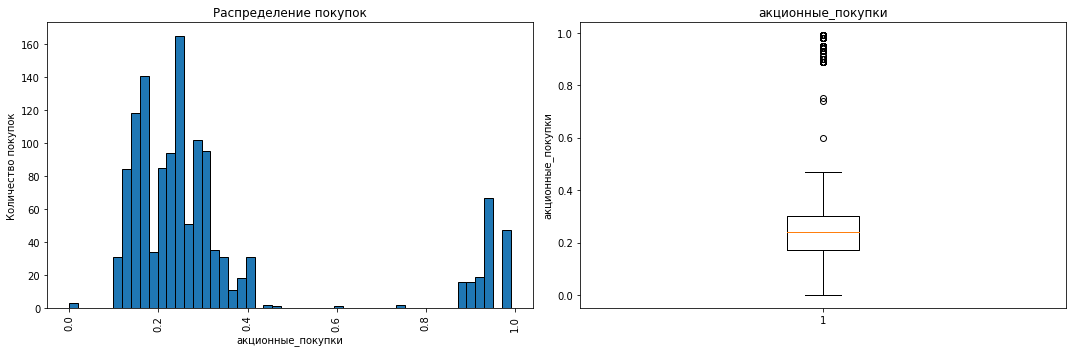

In [35]:
# Рассмотрим признак акционные_покупки
# Создание гистограммы и "ящика с усами" для признака "акционные_покупки"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_market_file['акционные_покупки'], bins=50, edgecolor='black')
plt.xlabel('акционные_покупки')
plt.ylabel('Количество покупок')
plt.title('Распределение покупок')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_market_file['акционные_покупки'])
plt.ylabel('акционные_покупки')
plt.title('акционные_покупки')

# Отображение графиков
plt.tight_layout()
plt.show()

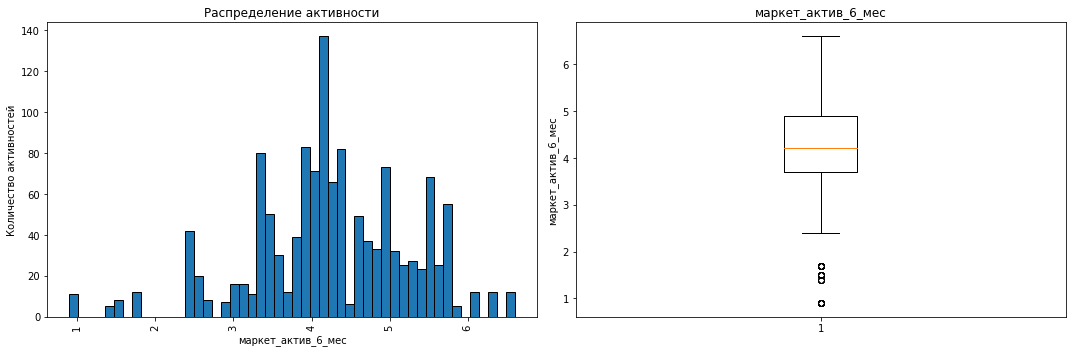

In [36]:
# Рассмотрим признак акционные_покупки
# Создание гистограммы и "ящика с усами" для признака "маркет_актив_6_мес"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_market_file['маркет_актив_6_мес'], bins=50, edgecolor='black')
plt.xlabel('маркет_актив_6_мес')
plt.ylabel('Количество активностей')
plt.title('Распределение активности')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_market_file['маркет_актив_6_мес'])
plt.ylabel('маркет_актив_6_мес')
plt.title('маркет_актив_6_мес')

# Отображение графиков
plt.tight_layout()
plt.show()

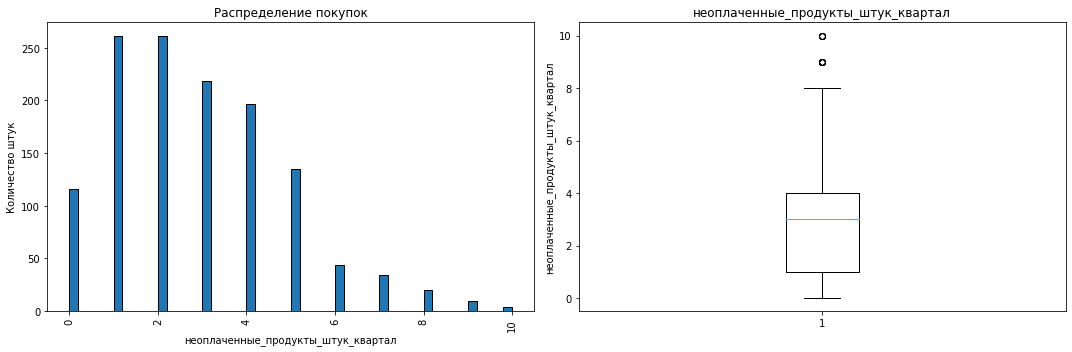

In [37]:
# Рассмотрим признак неоплаченные_продукты_штук_квартал
# Создание гистограммы и "ящика с усами" для признака "неоплаченные_продукты_штук_квартал"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_market_file['неоплаченные_продукты_штук_квартал'], bins=50, edgecolor='black')
plt.xlabel('неоплаченные_продукты_штук_квартал')
plt.ylabel('Количество штук')
plt.title('Распределение покупок')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_market_file['неоплаченные_продукты_штук_квартал'])
plt.ylabel('неоплаченные_продукты_штук_квартал')
plt.title('неоплаченные_продукты_штук_квартал')

# Отображение графиков
plt.tight_layout()
plt.show()

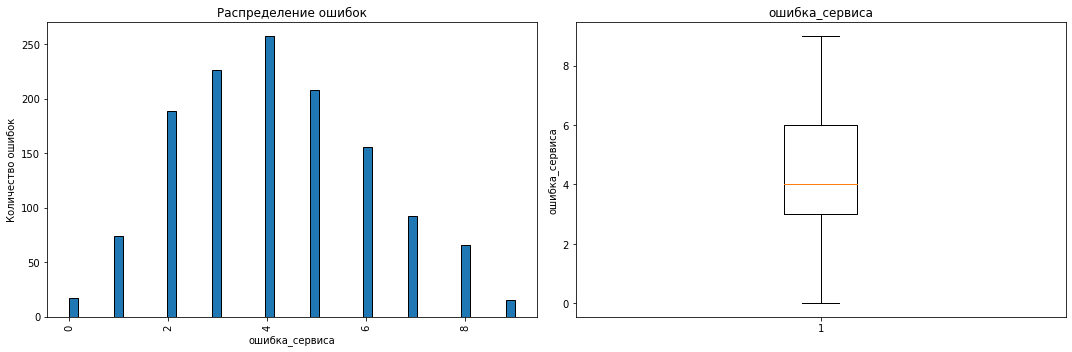

In [38]:
# Рассмотрим признак ошибка_сервиса
# Создание гистограммы и "ящика с усами" для признака "ошибка_сервиса"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_market_file['ошибка_сервиса'], bins=50, edgecolor='black')
plt.xlabel('ошибка_сервиса')
plt.ylabel('Количество ошибок')
plt.title('Распределение ошибок')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_market_file['ошибка_сервиса'])
plt.ylabel('ошибка_сервиса')
plt.title('ошибка_сервиса')

# Отображение графиков
plt.tight_layout()
plt.show()

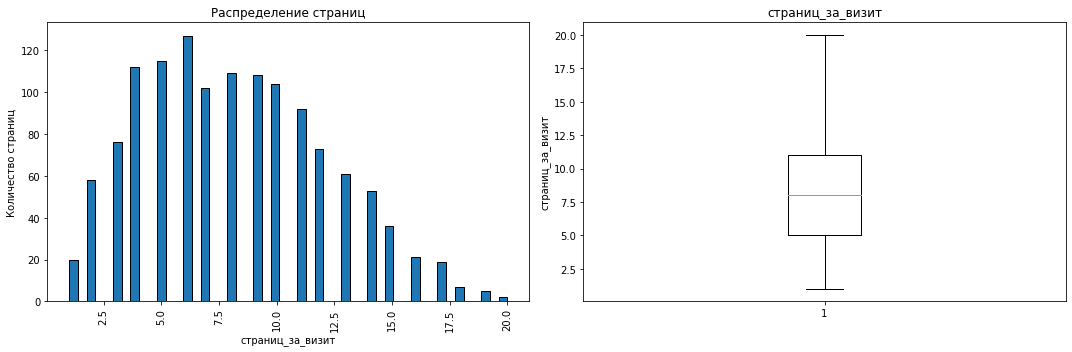

In [39]:
# Рассмотрим признак страниц_за_визит
# Создание гистограммы и "ящика с усами" для признака "страниц_за_визит"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_market_file['страниц_за_визит'], bins=50, edgecolor='black')
plt.xlabel('страниц_за_визит')
plt.ylabel('Количество страниц')
plt.title('Распределение страниц')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_market_file['страниц_за_визит'])
plt.ylabel('страниц_за_визит')
plt.title('страниц_за_визит')

# Отображение графиков
plt.tight_layout()
plt.show()

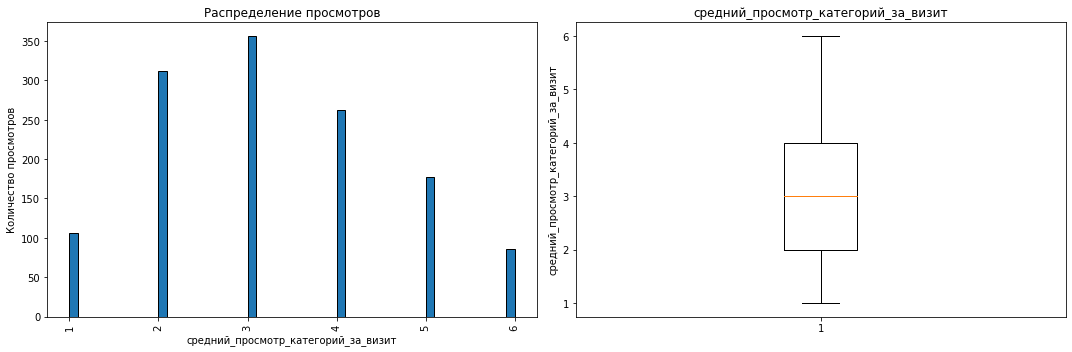

In [40]:
# Рассмотрим признак средний_просмотр_категорий_за_визит
# Создание гистограммы и "ящика с усами" для признака "средний_просмотр_категорий_за_визит"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_market_file['средний_просмотр_категорий_за_визит'], bins=50, edgecolor='black')
plt.xlabel('средний_просмотр_категорий_за_визит')
plt.ylabel('Количество просмотров')
plt.title('Распределение просмотров')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_market_file['средний_просмотр_категорий_за_визит'])
plt.ylabel('средний_просмотр_категорий_за_визит')
plt.title('средний_просмотр_категорий_за_визит')

# Отображение графиков
plt.tight_layout()
plt.show()

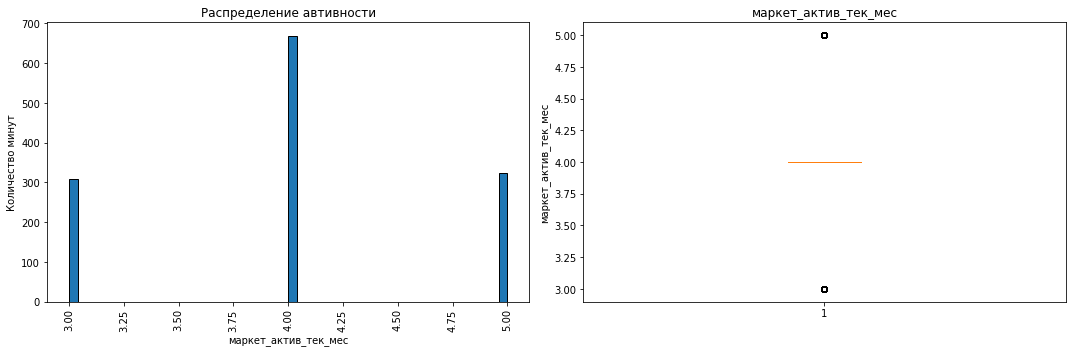

In [41]:
# Рассмотрим признак маркет_актив_тек_мес
# Создание гистограммы и "ящика с усами" для признака "маркет_актив_тек_мес"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_market_file['маркет_актив_тек_мес'], bins=50, edgecolor='black')
plt.xlabel('маркет_актив_тек_мес')
plt.ylabel('Количество минут')
plt.title('Распределение автивности')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_market_file['маркет_актив_тек_мес'])
plt.ylabel('маркет_актив_тек_мес')
plt.title('маркет_актив_тек_мес')

# Отображение графиков
plt.tight_layout()
plt.show()

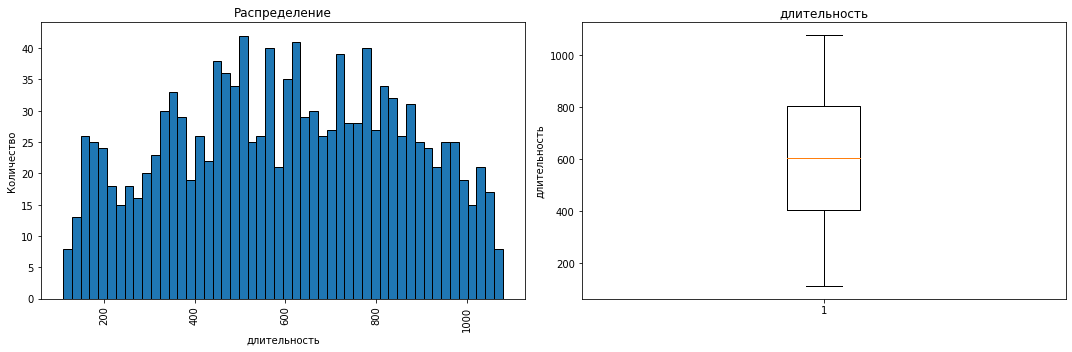

In [42]:
# Рассмотрим признак длительность
# Создание гистограммы и "ящика с усами" для признака "длительность"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_market_file['длительность'], bins=50, edgecolor='black')
plt.xlabel('длительность')
plt.ylabel('Количество')
plt.title('Распределение')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_market_file['длительность'])
plt.ylabel('длительность')
plt.title('длительность')

# Отображение графиков
plt.tight_layout()
plt.show()

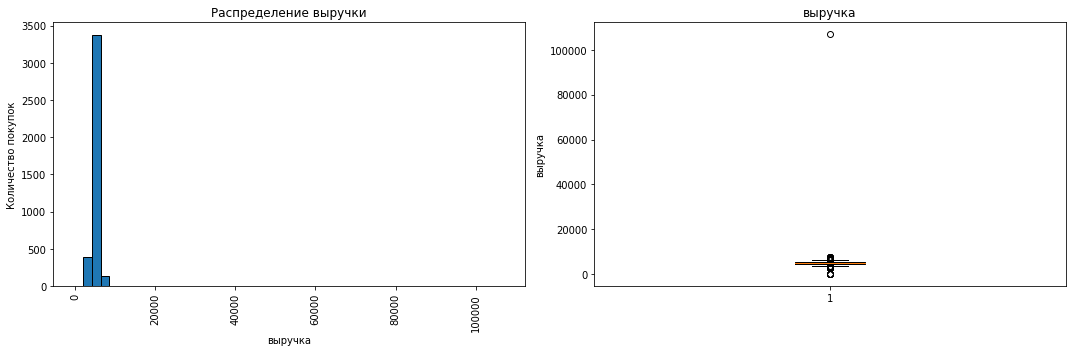

In [43]:
# Рассмотрим признак выручка
# Создание гистограммы и "ящика с усами" для признака "выручка"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_market_money['выручка'], bins=50, edgecolor='black')
plt.xlabel('выручка')
plt.ylabel('Количество покупок')
plt.title('Распределение выручки')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_market_money['выручка'])
plt.ylabel('выручка')
plt.title('выручка')

# Отображение графиков
plt.tight_layout()
plt.show()

In [44]:
# Определение выбросов с использованием границы прибыли в 20,000
anomalous_value = df_market_money[df_market_money['выручка'] > 20000]['выручка'].idxmax()

# Удаление найденного аномального значения
df_market_money = df_market_money.drop(index=anomalous_value)


<div class="alert alert-info">
исправила в этой ячейке
</div>

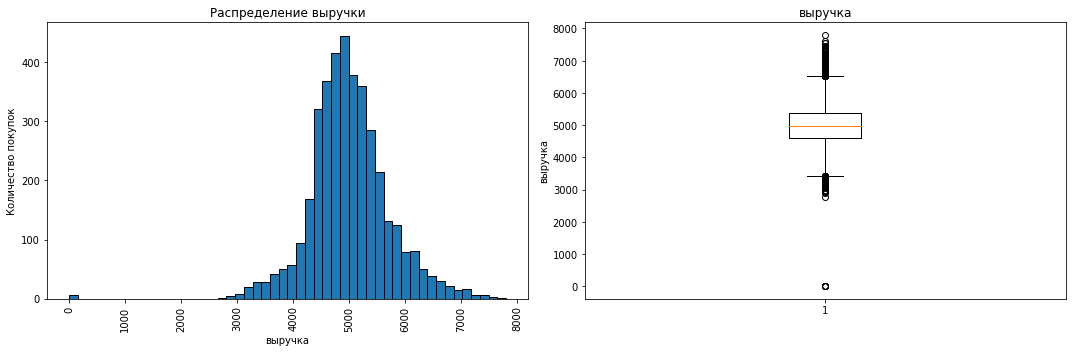

In [45]:
# Рассмотрим признак выручка
# Создание гистограммы и "ящика с усами" для признака "выручка"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_market_money['выручка'], bins=50, edgecolor='black')
plt.xlabel('выручка')
plt.ylabel('Количество покупок')
plt.title('Распределение выручки')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_market_money['выручка'])
plt.ylabel('выручка')
plt.title('выручка')

# Отображение графиков
plt.tight_layout()
plt.show()

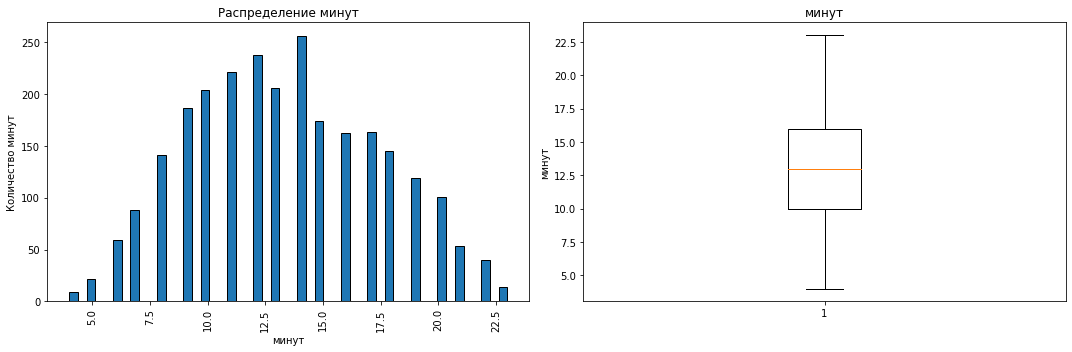

In [46]:
# Рассмотрим признак минут
# Создание гистограммы и "ящика с усами" для признака "минут"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_market_time['минут'], bins=50, edgecolor='black')
plt.xlabel('минут')
plt.ylabel('Количество минут')
plt.title('Распределение минут')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_market_time['минут'])
plt.ylabel('минут')
plt.title('минут')

# Отображение графиков
plt.tight_layout()
plt.show()

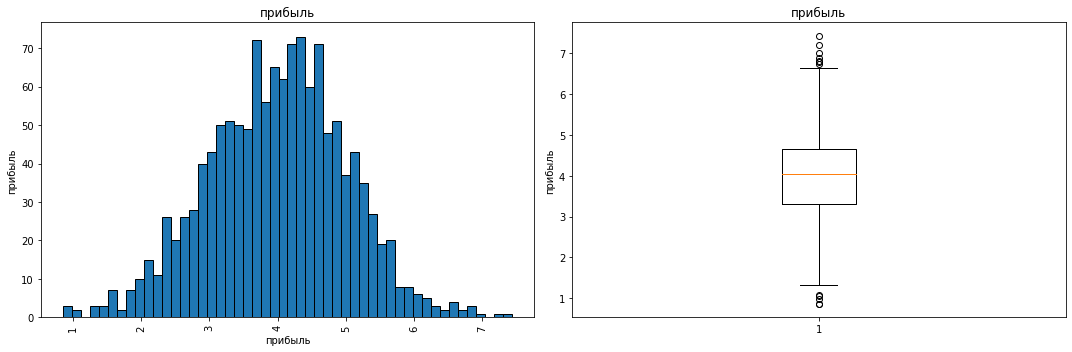

In [47]:
# Рассмотрим признак прибыль
# Создание гистограммы и "ящика с усами" для признака "прибыль"
plt.figure(figsize=(15, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(df_money['прибыль'], bins=50, edgecolor='black')
plt.xlabel('прибыль')
plt.ylabel('прибыль')
plt.title('прибыль')
plt.xticks(rotation=90)

# Ящик с усами
plt.subplot(1, 2, 2)
plt.boxplot(df_money['прибыль'])
plt.ylabel('прибыль')
plt.title('прибыль')

# Отображение графиков
plt.tight_layout()
plt.show()

В файле market_file есть выбросы в акционные_покупки, маркет_актив_6_мес, неоплаченные_продукты_штук_квартал, маркет_актив_тек_мес. В  файле money в столбце прибыль. Считаю, что данные выбросы нельзя удалять, так как может помешать работе. Удалили выброс в market_money в столбце выручка, так как он сильно испортит работу модели и аналитику.
Согласно гистограмма не нормальное распределение у длительности и акционных покупокю

Считаю, что анализ клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период, лучше сделать после объединения данных (шаг 5)

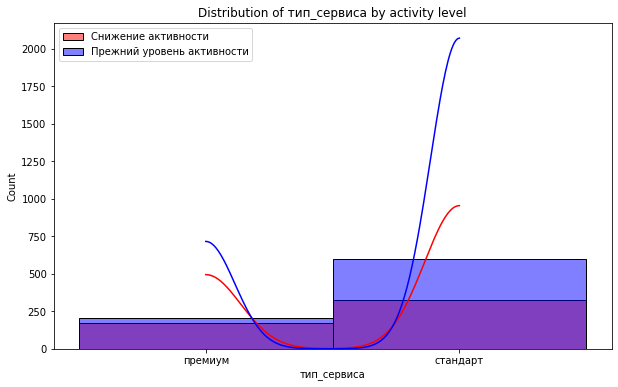

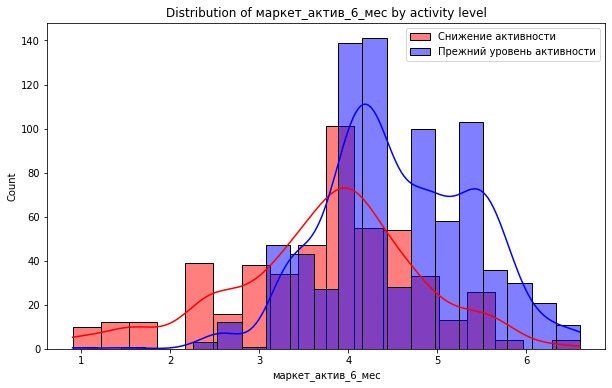

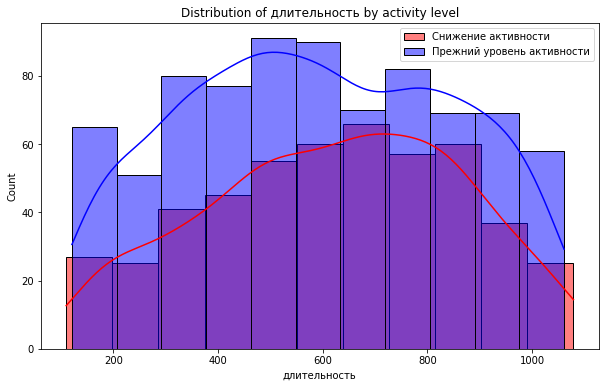

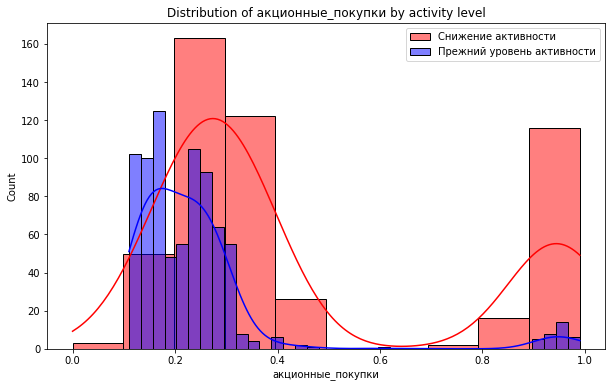

In [48]:
# Создаем подвыборку для покупателей с снижением активности
reduced_activity = df_market_file[df_market_file['покупательская_активность'] == 'Снизилась']

# Создаем подвыборку для покупателей с прежним уровнем активности
same_activity = df_market_file[df_market_file['покупательская_активность'] == 'Прежний уровень']

# Построем гистограммы для выбранных признаков
selected_features = ['тип_сервиса', 'маркет_актив_6_мес', 'длительность', 'акционные_покупки']
for feature in selected_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(reduced_activity[feature], color='r', kde=True, label='Снижение активности')
    sns.histplot(same_activity[feature], color='b', kde=True, label='Прежний уровень активности')
    plt.title(f'Distribution of {feature} by activity level')
    plt.legend()
    plt.show()


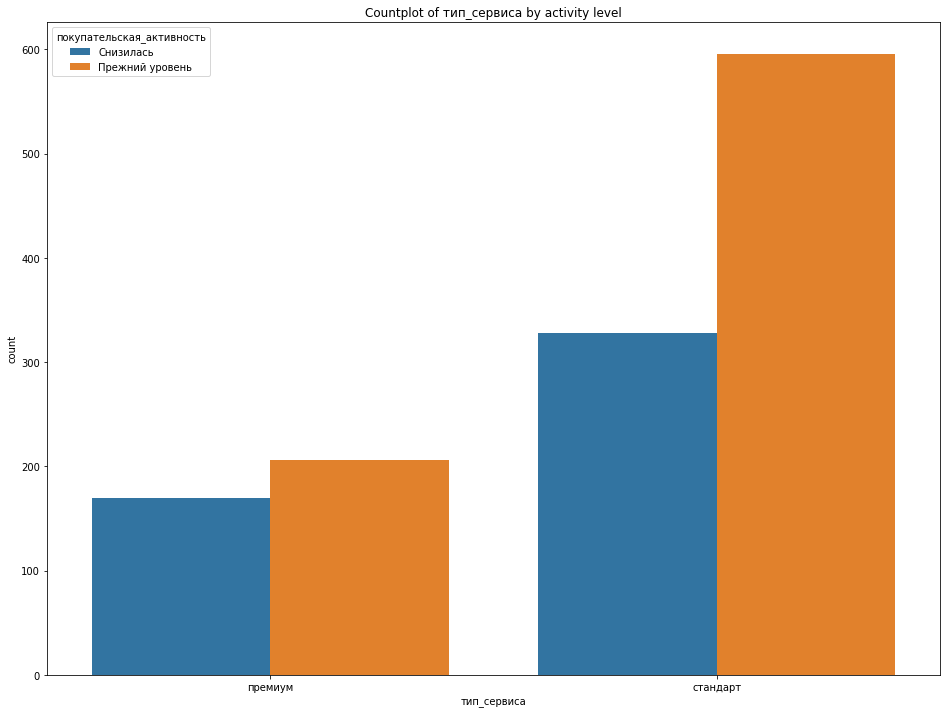

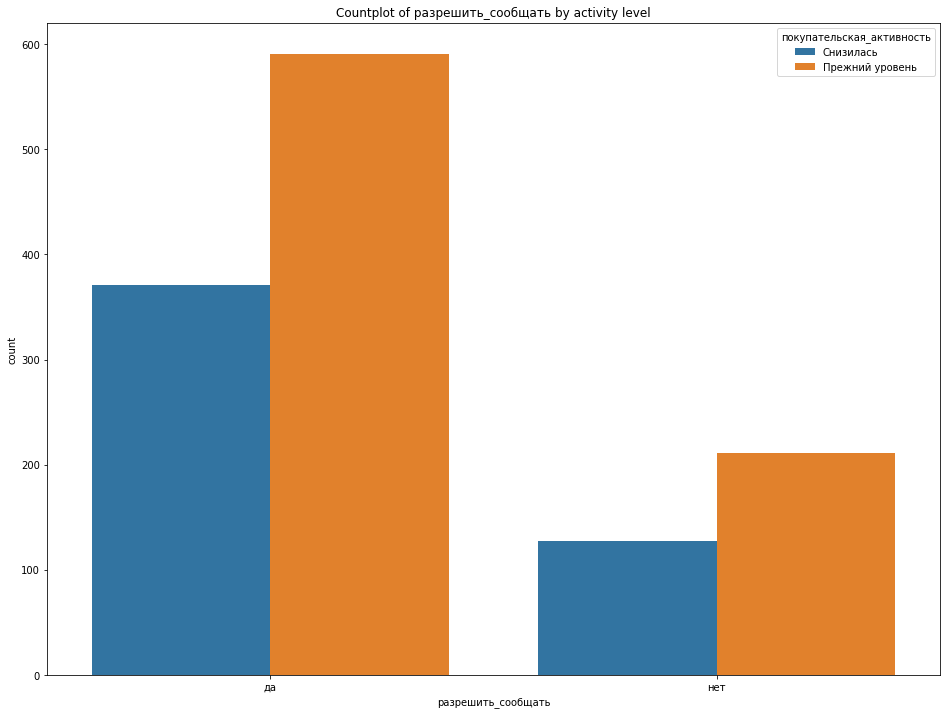

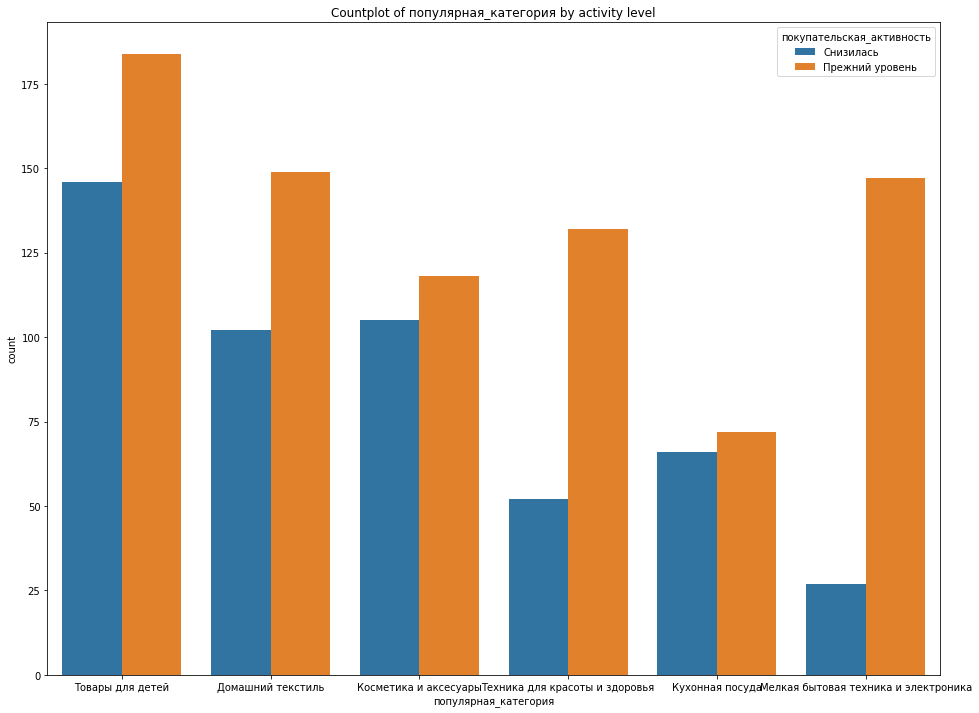

In [49]:
# Создаем подвыборку для категориальных признаков
categorical_features = ['тип_сервиса', 'разрешить_сообщать', 'популярная_категория']

for feature in categorical_features:
    plt.figure(figsize=(16, 12))
    sns.countplot(x=feature, hue='покупательская_активность', data=df_market_file)
    plt.title(f'Countplot of {feature} by activity level')
    plt.show()

В файле market_file тип сервиса - премиум остался на прежнем уровне, стандарт-понизился, маркет_актив_6_мес -при снижении активности уровень падает, длительность - при снижении активности уровень падает , акционные_покупки - переменно возрастают и снижаются. Из категорий сильно снизился уровень мелкой и бытовой техники, техника для красоты и здоровья.

## Объединение таблиц

4.1 Объединим таблицы market_file.csv, market_money.csv, market_time.csv. Учитываем, что данные о выручке и времени на сайте находятся в одном столбце для всех периодов. В итоговой таблице сделаем отдельный столбец для каждого периода.

In [50]:
# Шаг 1: Создание сводной таблицы по выручке и времени
df_money_pivot = df_market_money.pivot(index='id', columns='период', values='выручка')
time_pivot = df_market_time.pivot(index='id', columns='период', values='минут')

# Шаг 2: Объединение сводных таблиц
merged_data = df_market_file.merge(df_money_pivot, on='id').merge(time_pivot, on='id')

print(merged_data)

          id покупательская_активность тип_сервиса разрешить_сообщать  \
0     215348                 Снизилась     премиум                 да   
1     215349                 Снизилась     премиум                 да   
2     215350                 Снизилась    стандарт                нет   
3     215351                 Снизилась    стандарт                 да   
4     215352                 Снизилась    стандарт                нет   
...      ...                       ...         ...                ...   
1295  216643           Прежний уровень    стандарт                 да   
1296  216644           Прежний уровень    стандарт                нет   
1297  216645           Прежний уровень    стандарт                 да   
1298  216646           Прежний уровень    стандарт                 да   
1299  216647           Прежний уровень     премиум                 да   

      маркет_актив_6_мес  маркет_актив_тек_мес  длительность  \
0                    3.4                     5           12

In [51]:
merged_data.rename(columns={'предыдущий_месяц_x': 'выручка_предыдущий_месяц'}, inplace=True)
merged_data.rename(columns={'препредыдущий_месяц': 'выручка_препредыдущий_месяц'}, inplace=True)
merged_data.rename(columns={'текущий_месяц_x': 'выручка_текущий_месяц'}, inplace=True)
merged_data.rename(columns={'предыдущий_месяц_y': 'минут_предыдущий_месяц'}, inplace=True)
merged_data.rename(columns={'текущий_месяц_y': 'минут_текущий_месяц'}, inplace=True)

In [52]:
merged_data.head() # посмотрим информацию по данным
merged_data.info()
merged_data.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1300 entries, 0 to 1299
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   покупательская_активность            1300 non-null   object 
 2   тип_сервиса                          1300 non-null   object 
 3   разрешить_сообщать                   1300 non-null   object 
 4   маркет_актив_6_мес                   1300 non-null   float64
 5   маркет_актив_тек_мес                 1300 non-null   int64  
 6   длительность                         1300 non-null   int64  
 7   акционные_покупки                    1300 non-null   float64
 8   популярная_категория                 1300 non-null   object 
 9   средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  ошибка_сервиса                

(1300, 18)

In [53]:
# Проверка на пропуски
missing_values_fith = merged_data.isnull().sum()
missing_values_fith

id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
выручка_предыдущий_месяц               0
выручка_препредыдущий_месяц            0
выручка_текущий_месяц                  1
минут_предыдущий_месяц                 0
минут_текущий_месяц                    0
dtype: int64

In [54]:
# Удаление строк только из определенных столбцов, содержащих пропуски
merged_data = merged_data.dropna(subset=['выручка_текущий_месяц'])

In [55]:
# Проверка на пропуски
missing_values_fith = merged_data.isnull().sum()
missing_values_fith

id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
выручка_предыдущий_месяц               0
выручка_препредыдущий_месяц            0
выручка_текущий_месяц                  0
минут_предыдущий_месяц                 0
минут_текущий_месяц                    0
dtype: int64

In [56]:
merged_data.duplicated().sum() # проверяем файл merged_data на дубликаты

0

In [57]:
# Удаление дубликатов
merged_data = merged_data.drop_duplicates()

# Проверка, что дубликаты были удалены
merged_data.duplicated().sum()  # Проверяем, что больше нет дубликатов

0

In [58]:
merged_data.head() # посмотрим информацию по данным
merged_data.info()
merged_data.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1299 entries, 0 to 1299
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1299 non-null   int64  
 1   покупательская_активность            1299 non-null   object 
 2   тип_сервиса                          1299 non-null   object 
 3   разрешить_сообщать                   1299 non-null   object 
 4   маркет_актив_6_мес                   1299 non-null   float64
 5   маркет_актив_тек_мес                 1299 non-null   int64  
 6   длительность                         1299 non-null   int64  
 7   акционные_покупки                    1299 non-null   float64
 8   популярная_категория                 1299 non-null   object 
 9   средний_просмотр_категорий_за_визит  1299 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1299 non-null   int64  
 11  ошибка_сервиса                

(1299, 18)

In [59]:
# Удаление всех строк, содержащих хотя бы один пропуск
merged_data = merged_data.dropna()

In [60]:
# Проверка на пропуски
missing_values_fith = merged_data.isnull().sum()
missing_values_fith

id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
выручка_предыдущий_месяц               0
выручка_препредыдущий_месяц            0
выручка_текущий_месяц                  0
минут_предыдущий_месяц                 0
минут_текущий_месяц                    0
dtype: int64

In [61]:
merged_data.head() # посмотрим информацию по данным
merged_data.info()
merged_data.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1299 entries, 0 to 1299
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1299 non-null   int64  
 1   покупательская_активность            1299 non-null   object 
 2   тип_сервиса                          1299 non-null   object 
 3   разрешить_сообщать                   1299 non-null   object 
 4   маркет_актив_6_мес                   1299 non-null   float64
 5   маркет_актив_тек_мес                 1299 non-null   int64  
 6   длительность                         1299 non-null   int64  
 7   акционные_покупки                    1299 non-null   float64
 8   популярная_категория                 1299 non-null   object 
 9   средний_просмотр_категорий_за_визит  1299 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1299 non-null   int64  
 11  ошибка_сервиса                

(1299, 18)

In [62]:
is_nan_present = merged_data.isna().any().any()
is_nan_present

False

Объединили 3 таблицы. Четвертая- нам не требуется для обучения, сделали отдельный столбец для каждого периода. Проверили новые данные на пропуски и дубликаты, очистили от дубликатов

##  Корреляционный анализ

Проведем корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования.

In [63]:
names_num_columns = df_market_file.drop('id', axis=1).select_dtypes(include=[np.number]).columns.tolist()
names_num_columns

['маркет_актив_6_мес',
 'маркет_актив_тек_мес',
 'длительность',
 'акционные_покупки',
 'средний_просмотр_категорий_за_визит',
 'неоплаченные_продукты_штук_квартал',
 'ошибка_сервиса',
 'страниц_за_визит']

In [64]:
names_cat_columns = df_market_file.select_dtypes(exclude=[np.number]).columns.tolist()
names_cat_columns

['покупательская_активность',
 'тип_сервиса',
 'разрешить_сообщать',
 'популярная_категория']

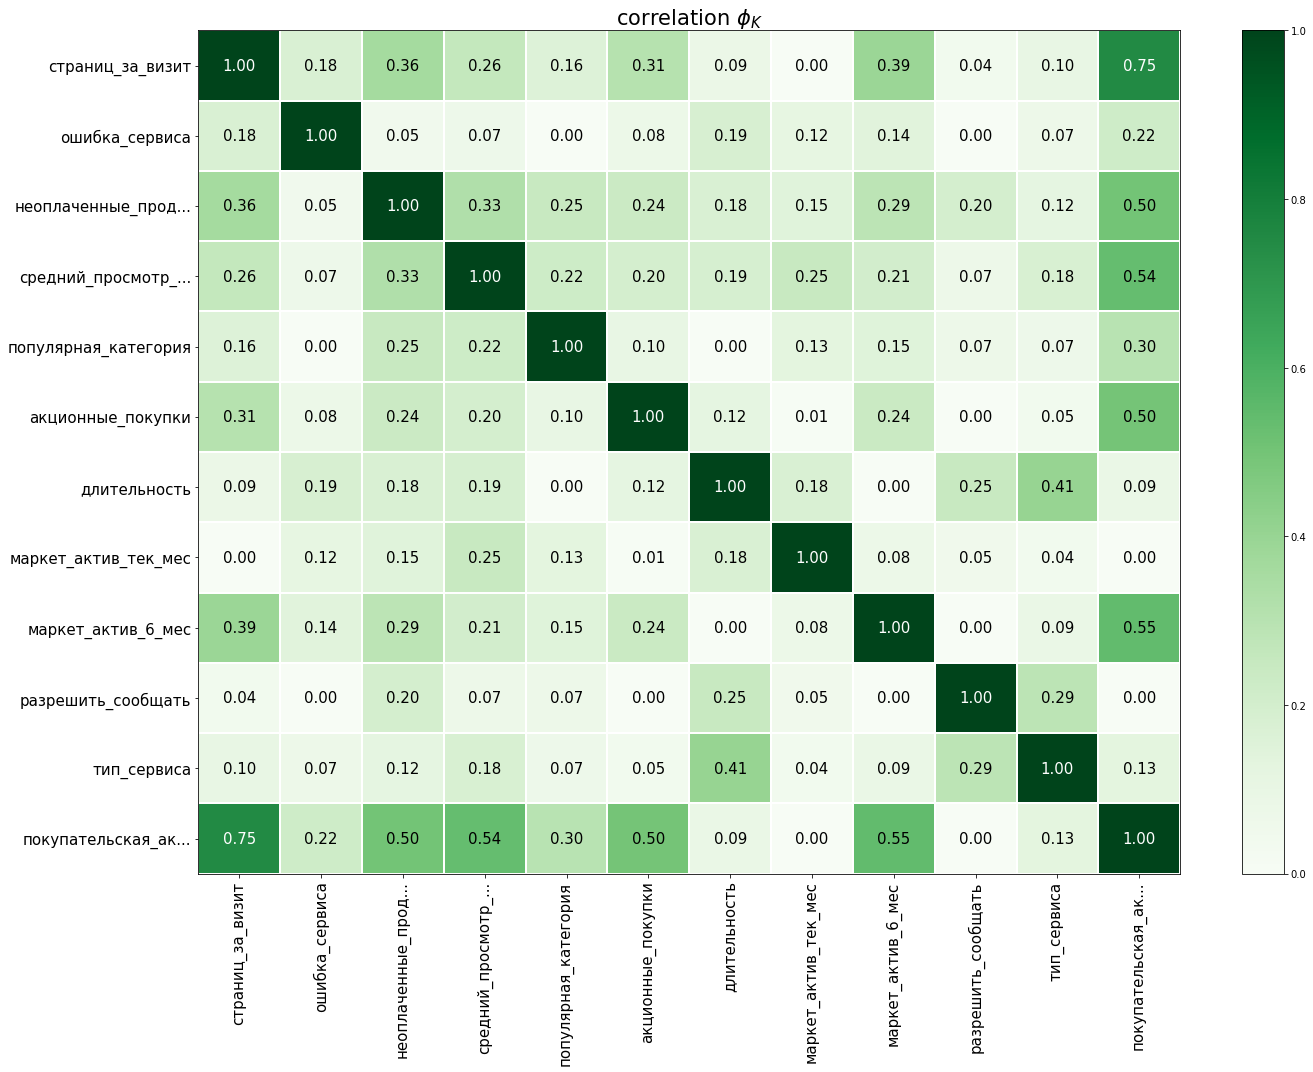

In [65]:
phik_overview = phik_matrix(df_market_file.drop('id', axis=1), interval_cols=names_num_columns)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

Отберем клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период. 

In [66]:
filtered_rows = []
for index, row in merged_data.iterrows():
    if (row['выручка_предыдущий_месяц'] > 0 and
        row['выручка_препредыдущий_месяц'] > 0 and
        row['выручка_текущий_месяц'] > 0):
        filtered_rows.append(row)

filtered_data = pd.DataFrame(filtered_rows, columns=merged_data.columns)

In [67]:
filtered_data.head() # посмотрим информацию по данным
filtered_data.info()
filtered_data.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 1 to 1299
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1296 non-null   int64  
 1   покупательская_активность            1296 non-null   object 
 2   тип_сервиса                          1296 non-null   object 
 3   разрешить_сообщать                   1296 non-null   object 
 4   маркет_актив_6_мес                   1296 non-null   float64
 5   маркет_актив_тек_мес                 1296 non-null   int64  
 6   длительность                         1296 non-null   int64  
 7   акционные_покупки                    1296 non-null   float64
 8   популярная_категория                 1296 non-null   object 
 9   средний_просмотр_категорий_за_визит  1296 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1296 non-null   int64  
 11  ошибка_сервиса                

(1296, 18)

In [68]:
filtered_data.duplicated().sum()  # проверяем файл merged_data на дубликаты

0

In [69]:
# Проверка на пропуски
missing_values_7 = filtered_data.isnull().sum()
missing_values_7

id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
выручка_предыдущий_месяц               0
выручка_препредыдущий_месяц            0
выручка_текущий_месяц                  0
минут_предыдущий_месяц                 0
минут_текущий_месяц                    0
dtype: int64

In [70]:
# Вычисление коэффициентов корреляции Пирсона
correlation_matrix = filtered_data.corr()

# Вывод матрицы корреляции
print(correlation_matrix)

                                           id  маркет_актив_6_мес  \
id                                   1.000000            0.353950   
маркет_актив_6_мес                   0.353950            1.000000   
маркет_актив_тек_мес                -0.006226            0.058673   
длительность                        -0.060275           -0.038987   
акционные_покупки                   -0.324270           -0.239086   
средний_просмотр_категорий_за_визит  0.271445            0.203207   
неоплаченные_продукты_штук_квартал  -0.294031           -0.165317   
ошибка_сервиса                       0.085184            0.034321   
страниц_за_визит                     0.499220            0.315082   
выручка_предыдущий_месяц            -0.053761            0.019636   
выручка_препредыдущий_месяц          0.348417            0.243668   
выручка_текущий_месяц               -0.086727            0.013102   
минут_предыдущий_месяц               0.480170            0.288165   
минут_текущий_месяц               

Мультиколлениарность отсутствует.

## Использование пайплайнов

Применим все изученные модели. Для этого используем пайплайны.

Перечислим особенности данных:
Четыри признака: тип сервиса, разрешить сообщать, популярная_категория и средний_просмотр_категорий_за_визит — нужно кодировать с помощью OneHotEncoder.
Пропусков нет, поэтому OrdinalEncoder не требуется.
Целевой признак — покупательская активность.

6.1 Во время подготовки данных используем ColumnTransformer. Количественные и категориальные признаки обработаем в пайплайне раздельно. Для кодирования категориальных признаков используем как минимум два кодировщика, для масштабирования количественных — как минимум два скейлера.
Напоминаем, что для каждой модели можно подготовить данные с разным кодированием и масштабированием.

In [71]:
df_market_file['покупательская_активность'].value_counts()

Прежний уровень    802
Снизилась          498
Name: покупательская_активность, dtype: int64

In [72]:
df_market_file['покупательская_активность'] = df_market_file['покупательская_активность'].apply(lambda x: 1 if x=='Снизилась' else 0)
df_market_file['покупательская_активность'].value_counts()

0    802
1    498
Name: покупательская_активность, dtype: int64

In [73]:
df_market_file = df_market_file.set_index('id')
df_market_file.head()

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
id,,,,,,,,,,,,
215348,1,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
215349,1,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
215350,1,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
215351,1,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
215352,1,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [74]:
names_cat_columns = ['тип_сервиса', 'разрешить_сообщать', 'популярная_категория']

In [75]:
names_num_columns

['маркет_актив_6_мес',
 'маркет_актив_тек_мес',
 'длительность',
 'акционные_покупки',
 'средний_просмотр_категорий_за_визит',
 'неоплаченные_продукты_штук_квартал',
 'ошибка_сервиса',
 'страниц_за_визит']

In [76]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

X = df_market_file.drop(['покупательская_активность'], axis=1)
y = df_market_file['покупательская_активность']

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=TEST_SIZE, 
                                                    random_state=RANDOM_STATE, 
                                                    stratify=y)

In [77]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe_ord', OneHotEncoder(drop='first', sparse_output=False), names_cat_columns),
        ('num', StandardScaler(), names_num_columns)
    ], 
    remainder='passthrough'
)

In [78]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
]) 

6.2 Обучим четыре модели: KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и SVC(). Для каждой из них подберем как минимум один гиперпараметр. Выберем подходящую для задачи метрику, аргументируем свой выбор. Используем эту метрику при подборе гиперпараметров.

In [79]:
param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 10),
        'models__max_features': range(2, 10),
        'preprocessor__ohe_ord': [OneHotEncoder(drop='first', sparse_output=False), OrdinalEncoder()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 100),
        'preprocessor__ohe_ord': [OneHotEncoder(drop='first', sparse_output=False), OrdinalEncoder()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', penalty='l1')],
        'models__C': [0.01, 0.1, 1, 10, 100],
        'preprocessor__ohe_ord': [OneHotEncoder(drop='first', sparse_output=False)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    # словарь для модели SVC()
    {
        'models': [SVC(kernel = 'poly', degree=2, probability=True, random_state=RANDOM_STATE)],
        'models__C': [0.01, 0.1, 1, 10, 100],
        'preprocessor__ohe_ord': [OneHotEncoder(drop='first', sparse_output=False)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },
    # словарь для модели SVC()
    {
        'models': [SVC(probability=True, random_state=RANDOM_STATE)],
        'models__kernel': ['rbf', 'sigmoid'],
        'models__C': [0.01, 0.1, 1, 10, 100],
        'preprocessor__ohe_ord': [OneHotEncoder(drop='first', sparse_output=False)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    }
]

6.3 Выберем лучшую модель, используя заданную метрику. Для этого применим одну из стратегий:
использовать пайплайны и инструменты подбора гиперпараметров для каждой модели отдельно, чтобы выбрать лучшую модель самостоятельно;
использовать один общий пайплайн для всех моделей и инструмент подбора гиперпараметров, который вернёт нам лучшую модель.

In [80]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_iter=150 
)

In [81]:
randomized_search.fit(X_train, y_train).best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_ord',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['тип_сервиса',
                                                   'разрешить_сообщать',
                                                   'популярная_категория']),
                                                 ('num', MinMaxScaler(),
                                                  ['маркет_актив_6_мес',
                                                   'маркет_актив_тек_мес',
                                                   'длительность',
                                                   'акционные_покупки',
                                                   'средний_просмотр_категорий_за_визит',
                                                   'неоплаченные_продукты_штук_квартал',
                                                   'ошибка_сервиса',
                                                   'страниц_за_визит'])])),
                ('models', SVC(C=10, probability=True, random_state=42))])

In [82]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_, '\n')
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_, '\n')

# проверим работу модели на тестовой выборке и рассчитаем прогноз на тестовых данных
y_pred = randomized_search.predict_proba(X_test)[:,1] 
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_ord',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['тип_сервиса',
                                                   'разрешить_сообщать',
                                                   'популярная_категория']),
                                                 ('num', MinMaxScaler(),
                                                  ['маркет_актив_6_мес',
                                                   'маркет_актив_тек_мес',
                                                   'длительность',
                                                   'акционные_покупки',
                                                   'средний_просмотр_катег

Лучшая модель - SVC(C=10, probability=True, random_state=42. Метрика 0,89 очень хороша.

Accuracy = 0.843
Recall = 0.758
Precision = 0.817
ROC AUC = 0.889


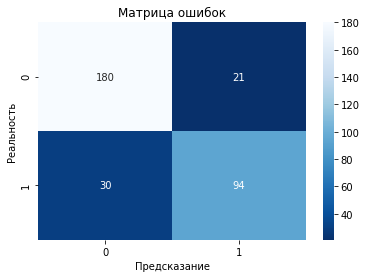

In [83]:
# Посчитаем метрики
model_metrics(randomized_search.best_estimator_, X_test, y_test)

Вывод: Лучшая модель SVC(C=0.1). Модель получила достаточно высокое качество: ROC AUC = 0,89 с лучшими показателями по тестовой выборке 0,89.

## 7.  Анализ важности признаков

7.1 Оценим важность признаков для лучшей модели и построем график важности с помощью метода SHAP. 

In [84]:
clf = randomized_search.best_estimator_['models']

In [85]:
test = X_test.copy()

In [86]:
test = randomized_search.best_estimator_['preprocessor'].transform(test)
test = pd.DataFrame(test, columns = randomized_search.best_estimator_['preprocessor'].get_feature_names_out())
test.shape

(325, 15)

7.2 Сделаем выводы о значимости признаков: какие признаки мало значимы для модели; какие признаки сильнее всего влияют на целевой признак; как можно использовать эти наблюдения при моделировании и принятии бизнес-решений.

PermutationExplainer explainer: 326it [00:28,  8.59it/s]                         


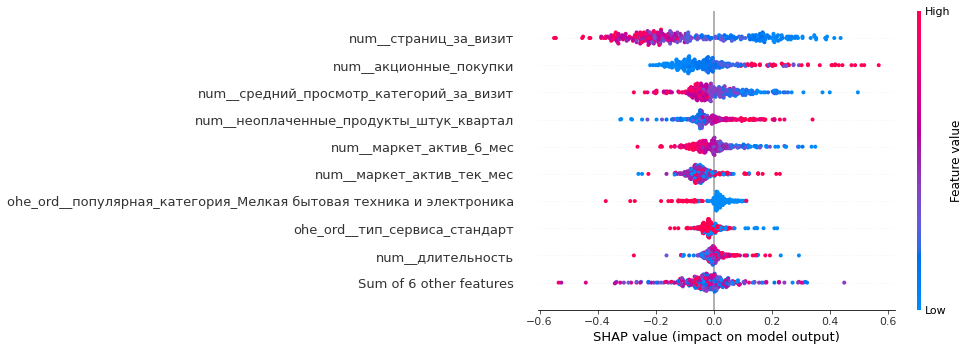

In [87]:
masker = shap.maskers.Independent(test.values, max_samples=10)

explainer = shap.explainers.Permutation(clf.predict, masker)
shap_values = explainer(test)

shap.plots.beeswarm(shap_values)

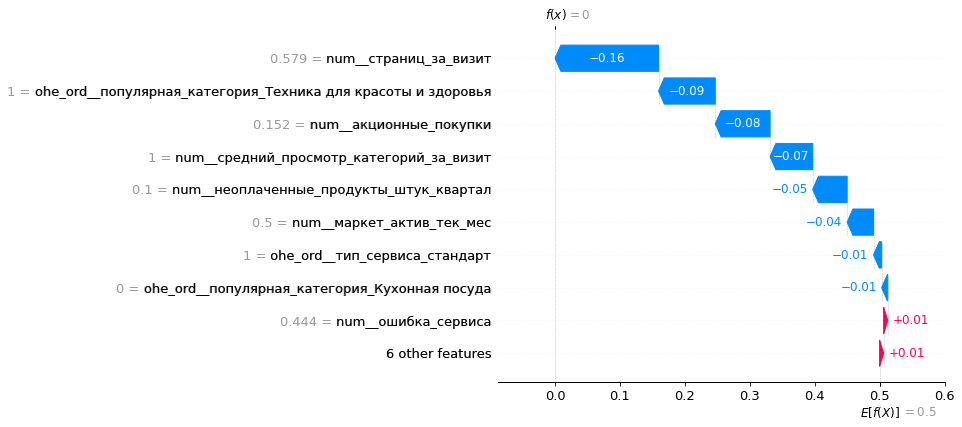

In [88]:
shap.plots.waterfall(shap_values[0]) 

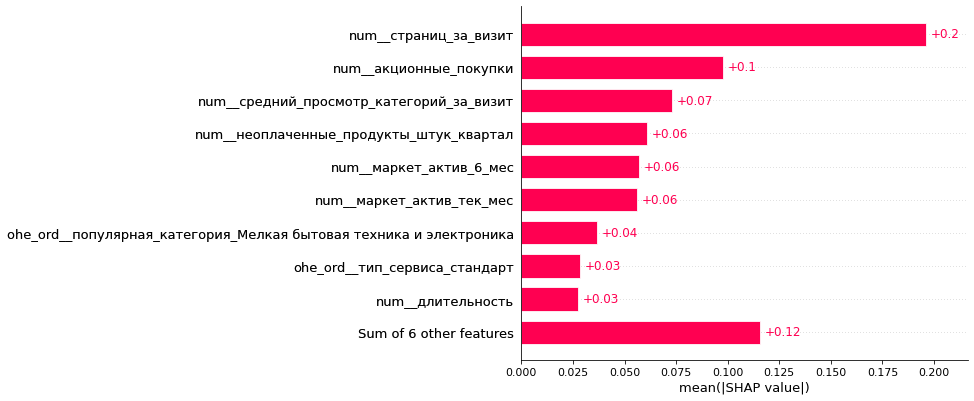

In [89]:
shap.plots.bar(shap_values)

 Самый значимимый признак страниц_за_визит. Это логично, так как чем больше клиент листает страниц, значит больше предложений его заинтересовало.  
Признак акционные_покупки также имеет высокую значимость, признак имеет обратную кореляцию с целевым, клиенты с большим количеством акционных покупок имеют большую вероятность снижения активности.
Признак неоплаченные покупки стоит на третьем месте. Можно рассмотреть в отдельном анализе более подробно данный признак. Наличие покупок в корзине говорит о том, что товар понравился и будут покупать в дальнейшем или что чем не утроил и скорее всего его уже не купят в данном магазине.

## 8. Сегментация покупателей

8.1 Выполните сегментацию покупателей. Используйте результаты моделирования и данные о прибыльности покупателей.

Выберем группу клиентов с высокой вероятностью снижения покупательской активности (0.8 и более) и наиболее высокой прибыльностью (20% самых прибыльных клиентов), для этого в исходный датасет добавим следующие столбцы:
* вероятность снижения активности (данные из нашей модели) 
* прибыль (данные из файла money)
* принадлежность к сегменту (значение "Да", если у клиента высокая вероятность снижения покупательской активности и высокая прибыльность, значение "Нет" все остальные клиенты)

In [90]:
y_true_labels = y_test # Истинные метки из вашего тестового набора данных

# Предсказание вероятностей классов для каждого покупателя
y_probabilities = randomized_search.predict_proba(X_test)[:,1]

y_probabilities[:10]

array([0.15161943, 0.9051613 , 0.07028283, 0.61518282, 0.93707175,
       0.14545325, 0.09741486, 0.19031705, 0.23433913, 0.71570345])

In [91]:
 #создаем новую колонку с вероятностями:
X_test['Вероятности снижения активности'] = y_probabilities
X_test.head(2)

,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,Вероятности снижения активности
id,,,,,,,,,,,,
216161,стандарт,да,4.1,4,606,0.15,Техника для красоты и здоровья,6,1,4,12,0.151619
215466,премиум,нет,2.4,5,523,0.30,Техника для красоты и здоровья,1,10,1,4,0.905161


In [92]:
X_train = X_train.join(y_train)
X_train['вероятность_снижения_активности'] = randomized_search.best_estimator_.predict_proba(X_train)[:,1]
X_train.head()

,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,покупательская_активность,вероятность_снижения_активности
id,,,,,,,,,,,,,
215535,стандарт,нет,2.6,3,302,0.31,Товары для детей,2,1,1,7,1,0.817316
216167,стандарт,нет,4.4,5,791,0.24,Кухонная посуда,3,1,4,8,0,0.184055
216241,премиум,да,6.1,3,668,0.17,Домашний текстиль,6,4,4,14,0,0.061621
215696,премиум,да,3.4,3,384,0.98,Кухонная посуда,1,9,4,3,1,0.990992
216417,премиум,да,4.6,3,485,0.23,Мелкая бытовая техника и электроника,2,5,7,13,0,0.031605


In [93]:
X_test = X_test.join(y_test)
X_test['вероятность_снижения_активности'] = randomized_search.best_estimator_.predict_proba(X_test)[:,1]
X_test.head()

,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,Вероятности снижения активности,покупательская_активность,вероятность_снижения_активности
id,,,,,,,,,,,,,,
216161,стандарт,да,4.1,4,606,0.15,Техника для красоты и здоровья,6,1,4,12,0.151619,0,0.151619
215466,премиум,нет,2.4,5,523,0.30,Техника для красоты и здоровья,1,10,1,4,0.905161,1,0.905161
216307,премиум,да,3.3,4,488,0.13,Домашний текстиль,4,2,8,10,0.070283,0,0.070283
215710,премиум,да,3.5,3,658,0.98,Товары для детей,3,0,2,5,0.615183,1,0.615183
215497,премиум,да,5.6,5,719,0.28,Мелкая бытовая техника и электроника,1,2,7,1,0.937072,1,0.937072


In [94]:
df_market_file = pd.concat([X_train, X_test], axis=0)
df_market_file.head()

,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,покупательская_активность,вероятность_снижения_активности,Вероятности снижения активности
id,,,,,,,,,,,,,,
215535,стандарт,нет,2.6,3,302,0.31,Товары для детей,2,1,1,7,1,0.817316,NaN
216167,стандарт,нет,4.4,5,791,0.24,Кухонная посуда,3,1,4,8,0,0.184055,NaN
216241,премиум,да,6.1,3,668,0.17,Домашний текстиль,6,4,4,14,0,0.061621,NaN
215696,премиум,да,3.4,3,384,0.98,Кухонная посуда,1,9,4,3,1,0.990992,NaN
216417,премиум,да,4.6,3,485,0.23,Мелкая бытовая техника и электроника,2,5,7,13,0,0.031605,NaN


In [95]:
print(df_money)

          id  прибыль
0     215348     0.98
1     215349     4.16
2     215350     3.13
3     215351     4.87
4     215352     4.21
...      ...      ...
1295  216643     4.44
1296  216644     6.11
1297  216645     3.29
1298  216646     4.03
1299  216647     3.28

[1300 rows x 2 columns]


In [96]:
df_money = df_money.set_index('id')
df_money.head()

,прибыль
id,
215348,0.98
215349,4.16
215350,3.13
215351,4.87
215352,4.21


In [97]:
df_market_file = df_market_file.join(df_money['прибыль'], how='left')
df_market_file.head()

,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,покупательская_активность,вероятность_снижения_активности,Вероятности снижения активности,прибыль
id,,,,,,,,,,,,,,,
215535,стандарт,нет,2.6,3,302,0.31,Товары для детей,2,1,1,7,1,0.817316,NaN,2.80
216167,стандарт,нет,4.4,5,791,0.24,Кухонная посуда,3,1,4,8,0,0.184055,NaN,4.36
216241,премиум,да,6.1,3,668,0.17,Домашний текстиль,6,4,4,14,0,0.061621,NaN,3.91
215696,премиум,да,3.4,3,384,0.98,Кухонная посуда,1,9,4,3,1,0.990992,NaN,2.88
216417,премиум,да,4.6,3,485,0.23,Мелкая бытовая техника и электроника,2,5,7,13,0,0.031605,NaN,6.40


In [98]:
# Функция для разбивки данных на сегмент
def segment(row):
    high_profit = np.quantile(df_market_file["прибыль"], 0.8)
    if row['вероятность_снижения_активности'] >= 0.8 and row['прибыль'] >= high_profit:
        return 'Да'
    else:
        return 'Нет'

In [99]:
df_market_file['принадлежность_к_сегменту'] = df_market_file.apply(segment, axis=1)

### Анализ сегмента 

Создадим функции для визуализации распределения данных в разрезе принадлежности к сегменту:

In [100]:
def plot_num_columns(df):
    names_num_columns = df.drop('покупательская_активность', axis=1).select_dtypes(include=[np.number]).columns.tolist()
    for name_column in names_num_columns:

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'Распределение признака {name_column}', fontsize=16)

        sns.histplot(data=df_market_file, x=name_column, ax=ax1, hue='принадлежность_к_сегменту')
        ax1.set_title(f'Гистограмма признака {name_column}')
        ax1.set_ylabel('Количество')

        sns.boxplot(data=df_market_file, x=name_column, ax=ax2, y='принадлежность_к_сегменту')
        ax2.set_title(f'Ящик с усами признака {name_column}')

        plt.show()

In [101]:
def plot_cat_columns(df):
    
    """Строит графики barplot по категориальным признакам."""
    
    names_cat_columns = ['тип_сервиса', 'разрешить_сообщать', 'популярная_категория', 'покупательская_активность']
    while len(names_cat_columns) > 0:
        plt.figure(figsize=(15, 5))
        for i in [1, 2]:
            if len(names_cat_columns) > 0:
                name_column = names_cat_columns.pop(0)
                plt.subplot(1, 2, i)
                sns.countplot(data=df_market_file, x=name_column, orient='h', hue='принадлежность_к_сегменту')
                plt.title(f'Распределение признака {name_column}')
                plt.ylabel('Количество')
                locs, labels = plt.xticks()
                plt.setp(labels, rotation=60)
            else:
                continue
        plt.show

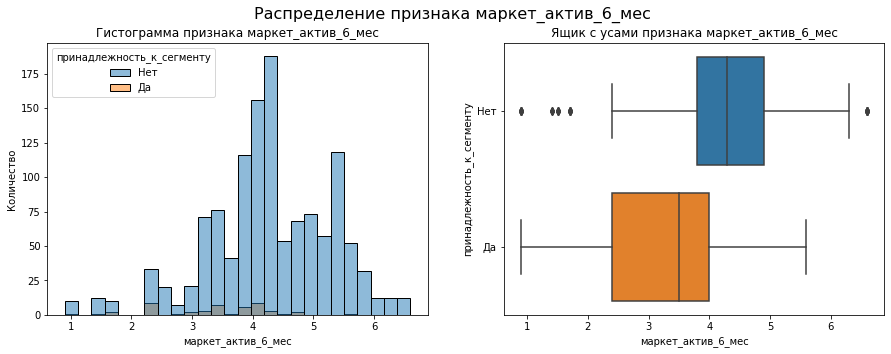

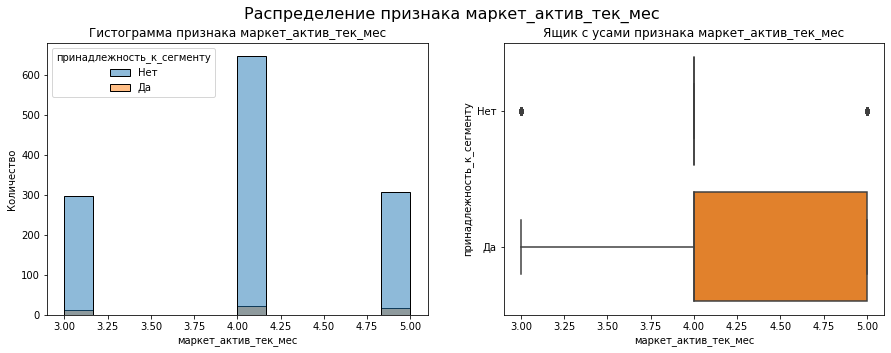

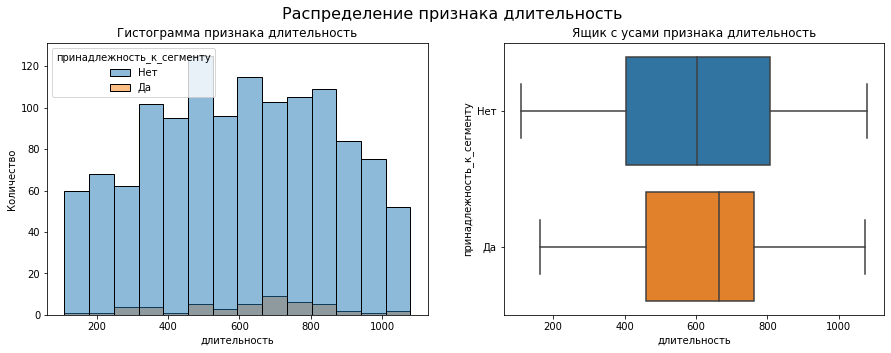

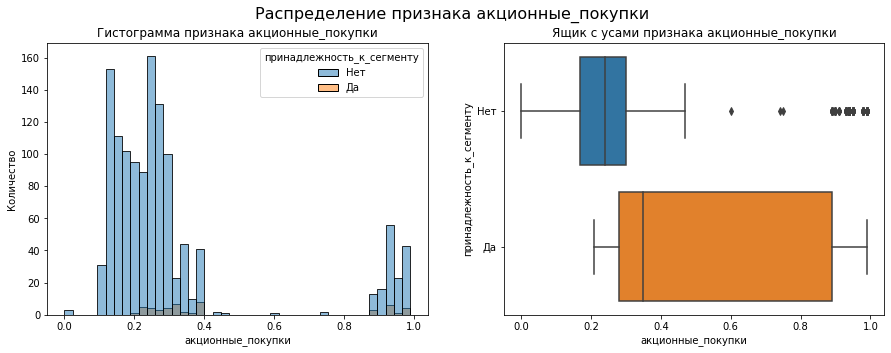

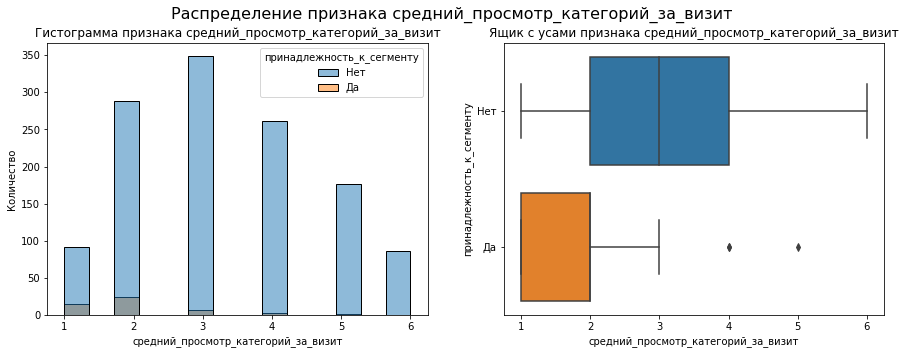

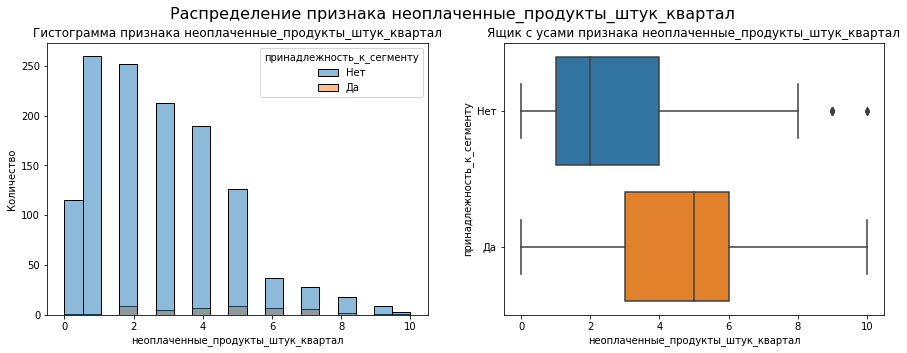

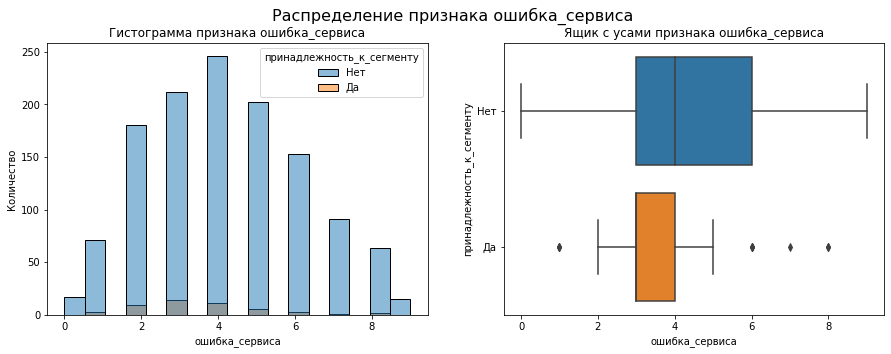

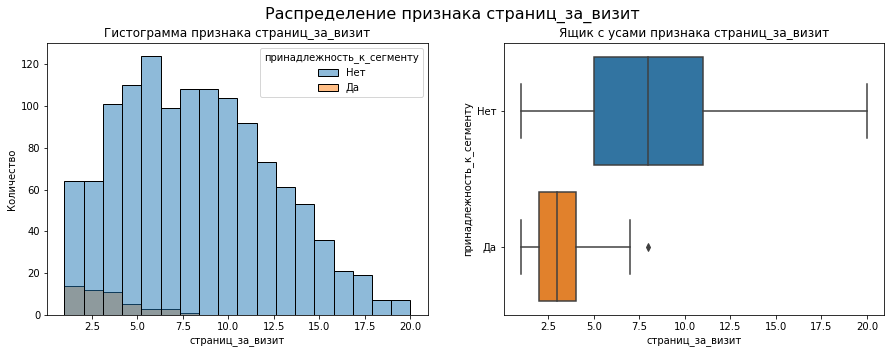

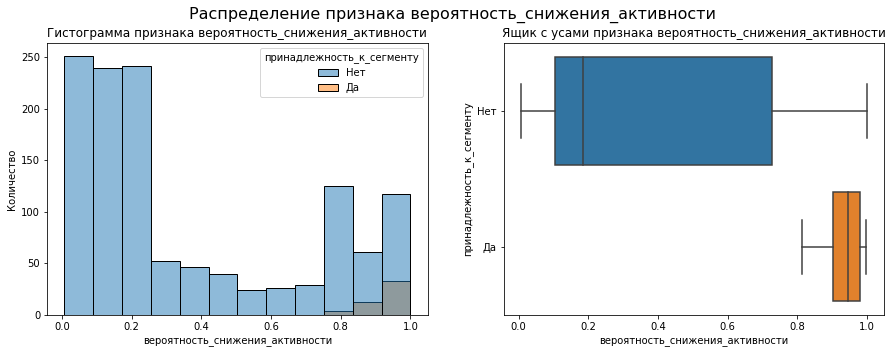

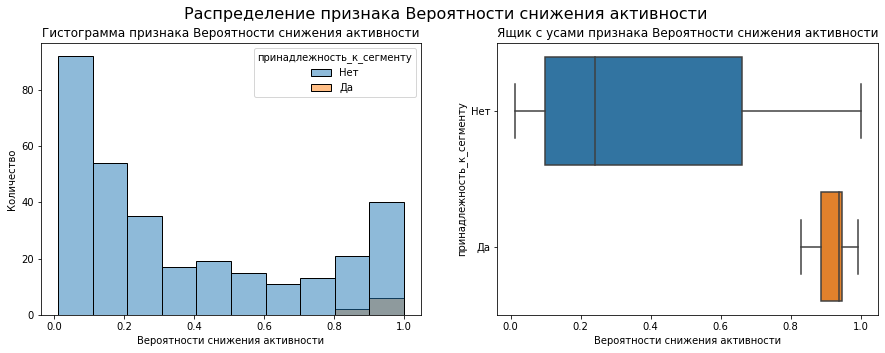

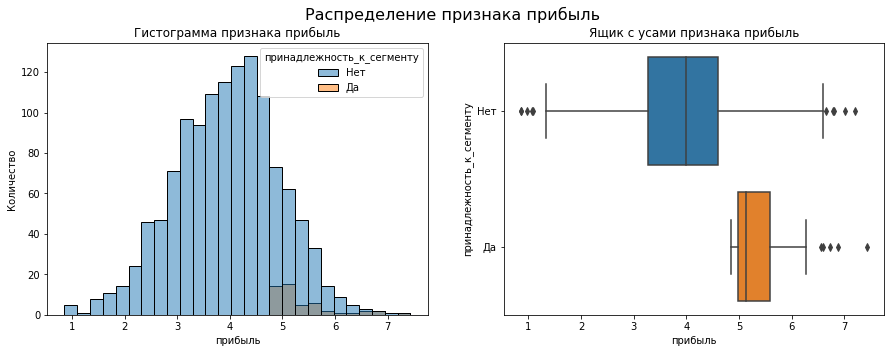

In [102]:
plot_num_columns(df_market_file)

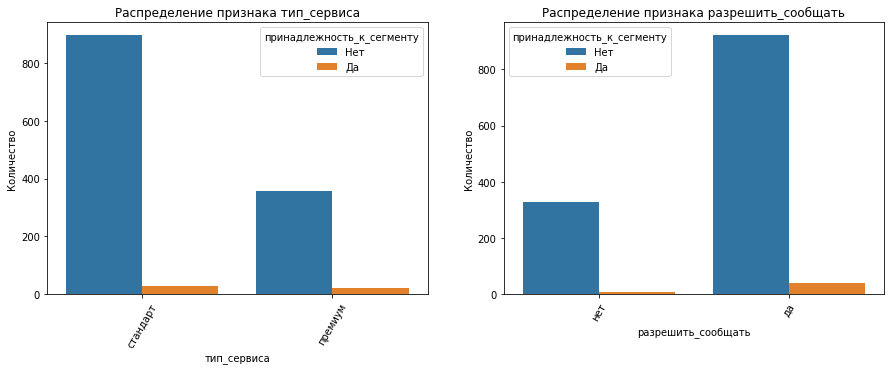

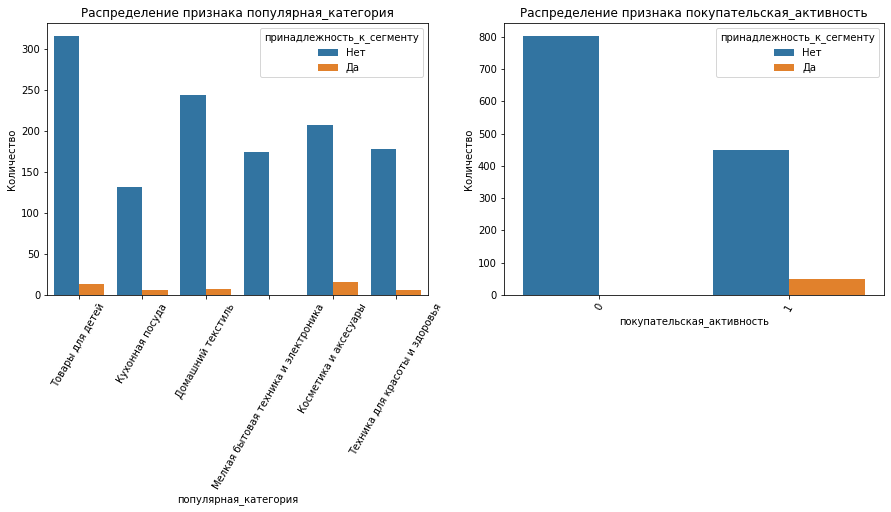

In [103]:
plot_cat_columns(df_market_file)

Посмотрим, как соотносятся категориальные признаки по сегменту:

* Тип сервиса:

In [104]:
df_market_file.query('принадлежность_к_сегменту == "Нет"')['тип_сервиса'].value_counts(normalize=True)

стандарт    0.715428
премиум     0.284572
Name: тип_сервиса, dtype: float64

In [105]:
df_market_file.query('принадлежность_к_сегменту == "Да"')['тип_сервиса'].value_counts(normalize=True)

стандарт    0.591837
премиум     0.408163
Name: тип_сервиса, dtype: float64

* Согласие покупателя на рассылку дополнительных предложений:

In [106]:
df_market_file.query('принадлежность_к_сегменту == "Нет"')['разрешить_сообщать'].value_counts(normalize=True)

да     0.736211
нет    0.263789
Name: разрешить_сообщать, dtype: float64

In [107]:
df_market_file.query('принадлежность_к_сегменту == "Да"')['разрешить_сообщать'].value_counts(normalize=True)

да     0.836735
нет    0.163265
Name: разрешить_сообщать, dtype: float64

* популярная категория:

In [108]:
df_market_file.query('принадлежность_к_сегменту == "Нет"')['популярная_категория'].value_counts(normalize=True)

Товары для детей                        0.252598
Домашний текстиль                       0.195044
Косметика и аксесуары                   0.165468
Техника для красоты и здоровья          0.142286
Мелкая бытовая техника и электроника    0.139089
Кухонная посуда                         0.105516
Name: популярная_категория, dtype: float64

In [109]:
df_market_file.query('принадлежность_к_сегменту == "Да"')['популярная_категория'].value_counts(normalize=True)

Косметика и аксесуары             0.326531
Товары для детей                  0.285714
Домашний текстиль                 0.142857
Кухонная посуда                   0.122449
Техника для красоты и здоровья    0.122449
Name: популярная_категория, dtype: float64

8.3 Сделаем выводы о сегментах:
какой сегмент взяла для дополнительного исследования,
какие предложения сделала и почему.

**Вывод:** 
  В группе клиентов с высокой вероятностью снижения покупательской активности (0.8 и более) и наиболее высокой прибыльностью (20% самых прибыльных клиентов) можно заметить следующее:
* среднемесячное значение маркетинговых коммуникаций, которое приходилось на покупателя за последние 6 месяцев ниже чем у остальных клиентов, при этом количество маркетинговых коммуникаций в текущем месяце не отличается в двух группах;
* среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев выше, чем у остальных клиентов; 
* время, проведенное на сайте и количество просмотренных категорий ниже чем у остальных клиентов;
* общее число неоплаченных товаров в корзине за последние 3 месяца выше чем у остальных клиентов;
* выручка за препредыдущий месяц ниже, при этом выручка за предыдущий не отличается, а за текущий месяц выше;
* самые популярные категории: косметика и аксессуары, товары для детей и домашний текстиль. 

Для увеличения покупательской активности в выбранном сегменте можно предложить следующие шаги:
* активная работа с данным сегментов (новые предложения, спец. акции);
* клиенту можно показывать дополнительный товар на популярных страницах, тем самым увеличится время присутствия клиента на сайте и количество просмотренных категорий;
* присмотреться к акционным покупкам, модель показала, что чем больше у клиента акционных покупок тем  больше у клиента вероятность снижения активности;
* можно делать напоминания клиенту о том, что в корзине есть неоплаченый товар.

## 9. Общий вывод

опишите задачу;
опишите исходные данные и проведённую предобработку;
напишите, что вы сделали для поиска лучшей модели;
укажите лучшую модель;
добавьте выводы и дополнительные предложения для выбранного сегмента покупателей.

Опишем задачу:
Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца и сделать рекомендации для персонализации предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

У нас есть 4 файла с данными.
Проверили данные на читаемость, форматы, дубликаты и пропуски. Все файлы привели к единому рабочему виду. Провели статистический и корреляционный анализ всех признаков.

С помощью паплайнов создали модель для отбора. Вывод: Лучшая модель SVC(C=0.1). Модель получила достаточно высокое качество: ROC AUC = 0,89 с лучшими показателями по тестовой выборке 0,89.

С помощью метода SHAP мы оценили наиболее важные признаки.
 Самый значимимый признак страниц_за_визит, также у данного признака самая большая корреляция с целевым признаком 0,75 и это логично, так как чем больше клиент листает страниц, значит больше предложений его заинтересовало.  
Признак акционные_покупки также имеет высокую значимость, признак имеет обратную кореляцию с целевым, клиенты с большим количеством акционных покупок имеют большую вероятность снижения активности.
Признак неоплаченные покупки стоит на третьем месте. Можно рассмотреть в отдельном анализе более подробно данный признак. Наличие покупок в корзине говорит о том, что товар понравился и будут покупать в дальнейшем или что чем не утроил и скорее всего его уже не купят в данном магазине.

  В группе клиентов с высокой вероятностью снижения покупательской активности (0.8 и более) и наиболее высокой прибыльностью (20% самых прибыльных клиентов) можно заметить следующее:
* среднемесячное значение маркетинговых коммуникаций, которое приходилось на покупателя за последние 6 месяцев ниже чем у остальных клиентов, при этом количество маркетинговых коммуникаций в текущем месяце не отличается в двух группах;
* среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев выше, чем у остальных клиентов; 
* время, проведенное на сайте и количество просмотренных категорий ниже чем у остальных клиентов;
* общее число неоплаченных товаров в корзине за последние 3 месяца выше чем у остальных клиентов;
* выручка за препредыдущий месяц ниже, при этом выручка за предыдущий не отличается, а за текущий месяц выше;
* самые популярные категории: косметика и аксессуары, товары для детей и домашний текстиль. 

Для увеличения покупательской активности в выбранном сегменте можно предложить следующие шаги:
* активная работа с данным сегментов (новые предложения, спец. акции);
* клиенту можно показывать дополнительный товар на популярных страницах, тем самым увеличится время присутствия клиента на сайте и количество просмотренных категорий;
* присмотреться к акционным покупкам, модель показала, что чем больше у клиента акционных покупок тем  больше у клиента вероятность снижения активности;
* можно делать напоминания клиенту о том, что в корзине есть неоплаченый товар.

Рекомендации: 
На данный момент можно предложить следующие меры для увеличения покупательской активности:

Повышение уровня персонализации: Используя информацию о предпочтениях и поведении покупателей, можно предложить персонализированные рекомендации и предложения, что может стимулировать их активность.

Акционные предложения: Используя данные об акционных покупках и общем объеме покупок, можно создать целевые акционные предложения для данной группы покупателей, что может привести к повышению их покупательской активности.

Улучшение сервиса: Анализируя данные об ошибках сервиса и обратной связи от покупателей, можно выявить и устранить проблемы, что сделает процесс покупок более комфортным и удобным для данной группы покупателей.

Маркетинговая активность: Используя данные о предыдущих маркетинговых активностях и их влиянии на покупательское поведение, можно разработать специальные маркетинговые кампании, направленные на увеличение активности данной группы покупателей.